# **MÓDULO 33 - Projeto Final de Modelos Avançados**

**Objetivo do Projeto:**

O objetivo deste projeto é aplicar os conceitos aprendidos nos módulos de conceitos avançados de modelagem para realizar uma segmentação de clientes utilizando o algoritmo de clustering K-Means. Ao final do projeto, você terá a oportunidade de consolidar seus conhecimentos em exploração de dados, pré-processamento, implementação e avaliação de modelos.

**Exploração de Dados:**

Inicie explorando o dataset fornecido, buscando entender as principais características das variáveis e a distribuição dos dados.

Realize análises descritivas, identifique padrões, e verifique a presença de valores ausentes ou inconsistências que precisem ser tratadas.

**Tratamento de Dados:**

Realize os tratamentos necessários como limpeza de dados, normalização ou padronização das variáveis, e, se necessário, a criação de variáveis derivadas.

Documente cada etapa do tratamento, explicando o motivo das escolhas feitas e como elas impactam no modelo.

**Implementação do Algoritmo K-Means:**

Aplique o algoritmo K-Means no dataset tratado. Defina o número de clusters (k).
Execute o algoritmo, ajuste os parâmetros conforme necessário, e documente o processo.

**Avaliação e Interpretação dos Resultados:**

Avalie a qualidade dos clusters gerados utilizando métricas adequadas.

Interprete os resultados, descrevendo as características de cada cluster e como eles podem ser utilizados para a segmentação de clientes.

Sugira aplicações práticas para os clusters identificados, como estratégias de marketing direcionadas ou personalização de ofertas.

**O dataset a ser utilizado neste projeto contém informações de 200 clientes, com os seguintes atributos:**

CustomerID: Identificador único atribuído a cada cliente.

Gender: Gênero do cliente.

Age: Idade do cliente.

Annual Income (k$): Renda anual do cliente em milhares de dólares.

Spending Score (1-100): Pontuação atribuída pelo shopping com base no
comportamento e padrão de gastos do cliente.

Notem que neste projeto vocês terão autonomia para criar os passos e justificar, sempre, os passos escolhidos.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1) Exploração de Dados



In [2]:
df = pd.read_csv("Mall_Customers.csv")

df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [ ]:
# Verificando os tipos de dados

df.dtypes

CustomerID                int64
Gender                      str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

In [ ]:
# Verificando valores ausentes

df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

A base não possui nenhum valor ausente em nenhuma coluna, então não é necessário nenhum tratamento de remoção ou substituição nesta etapa.



In [ ]:
# Resumo estatístico das variáveis numéricas

df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


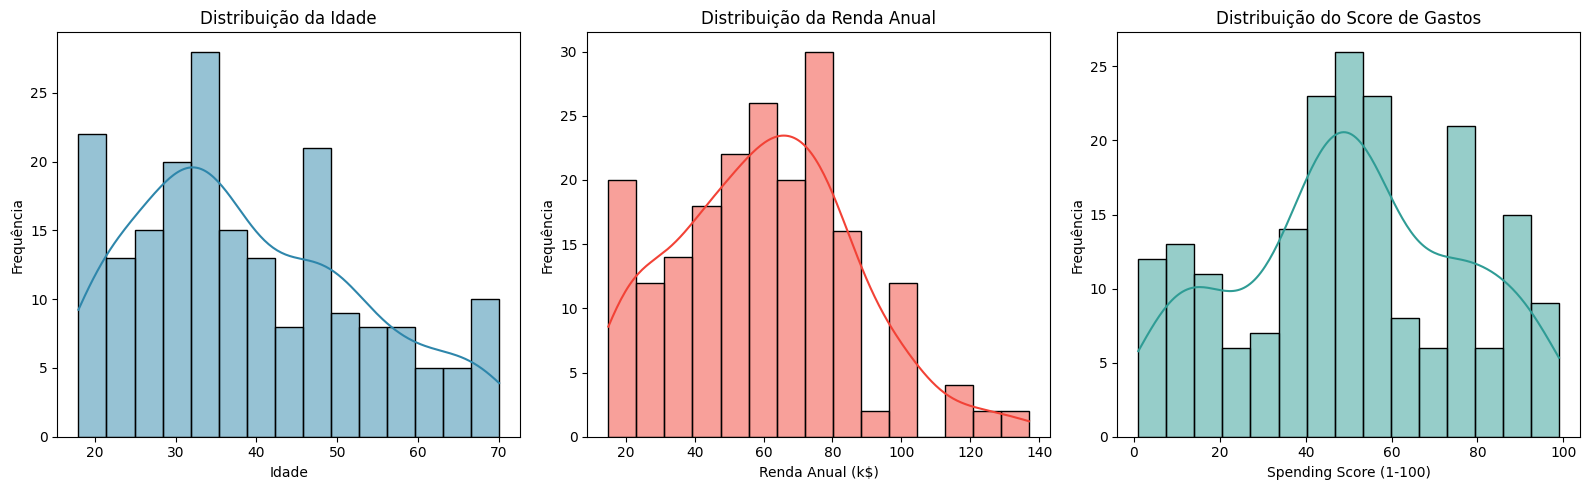

In [ ]:
# Distribuição das variáveis numéricas

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.histplot(df['Age'], bins=15, kde=True, color='#2E86AB', ax=axes[0])
axes[0].set_title('Distribuição da Idade')
axes[0].set_xlabel('Idade')
axes[0].set_ylabel('Frequência')

sns.histplot(df['Annual Income (k$)'], bins=15, kde=True, color='#F24236', ax=axes[1])
axes[1].set_title('Distribuição da Renda Anual')
axes[1].set_xlabel('Renda Anual (k$)')
axes[1].set_ylabel('Frequência')

sns.histplot(df['Spending Score (1-100)'], bins=15, kde=True, color='#2F9C95', ax=axes[2])
axes[2].set_title('Distribuição do Score de Gastos')
axes[2].set_xlabel('Spending Score (1-100)')
axes[2].set_ylabel('Frequência')

plt.tight_layout()
plt.show()

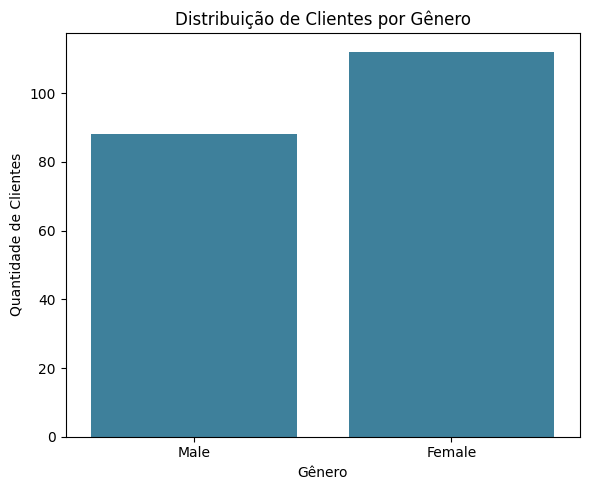

In [ ]:
# Distribuição por gênero

plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='Gender', color='#2E86AB')
plt.title('Distribuição de Clientes por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Quantidade de Clientes')
plt.tight_layout()
plt.show()

A base tem uma distribuição um pouco maior de mulheres do que de homens. A idade dos clientes varia de 18 a 70 anos, com boa dispersão ao longo de toda a faixa. A renda anual varia de 15k a 137k dólares, e o score de gastos varia de 1 a 99, ambos cobrindo praticamente toda a escala possível, o que é positivo para o clustering, já que indica clientes com perfis bem variados, sem uma concentração excessiva em uma única faixa.



In [ ]:
# Verificando outliers pelo método do IQR nas variáveis numéricas

for col in ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]
    print(f'{col}: {len(outliers)} outlier(s)')

Age: 0 outlier(s)
Annual Income (k$): 2 outlier(s)
Spending Score (1-100): 0 outlier(s)


Foram encontrados apenas 2 outliers, e somente na variável Annual Income (k$), o que representa uma fração muito pequena da base (1%). Como o K-means pode ser sensível a valores extremos, esses casos foram observados com atenção, mas optou-se por mantê-los na base, já que são poucos pontos e removê-los reduziria ainda mais uma base já pequena (200 clientes), além de esses clientes de renda mais alta representarem um perfil real e relevante para a segmentação de um shopping.



# 2) Tratamento de Dados



In [ ]:
# Codificando a variável Gender para uso posterior na análise dos clusters

df['Gender_Cod'] = df['Gender'].map({'Male': 0, 'Female': 1})

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Gender_Cod
0,1,Male,19,15,39,0
1,2,Male,21,15,81,0
2,3,Female,20,16,6,1
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1


Optou-se por não incluir Gender diretamente nas variáveis usadas para o K-means, mantendo apenas Annual Income (k$) e Spending Score (1-100), que são as variáveis clássicas para esse tipo de segmentação de comportamento de consumo. A variável Age foi testada como uma terceira dimensão do cluster, porém a comparação de métricas (feita mais adiante) mostrou que usar apenas renda e score de gastos gera clusters mais bem definidos e mais fáceis de interpretar para fins de marketing. Ainda assim, tanto Age quanto Gender são usados depois, para descrever o perfil de cada cluster encontrado.



In [ ]:
# Selecionando as variáveis que serão usadas no Kmeans

colunas_cluster = ['Annual Income (k$)', 'Spending Score (1-100)']
X = df[colunas_cluster]

# Padronizando as variáveis, deixando ambas na mesma escala (média 0, desvio padrão 1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

A padronização é importante mesmo com apenas duas variáveis, já que Annual Income (k$) varia numa escala de dezenas a centenas, enquanto Spending Score (1-100) varia numa escala menor. Sem padronizar, a renda dominaria o cálculo de distância do K-means, distorcendo a formação dos clusters.



# 3) Implementação do Algoritmo K-Means



In [ ]:
# Testando diferentes valores de k, usando o método do cotovelo (inércia) e o silhouette score

inertias = []
silhouettes = []
valores_k = range(2, 11)

for k in valores_k:
    kmeans_teste = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_teste = kmeans_teste.fit_predict(X_scaled)
    inertias.append(kmeans_teste.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels_teste))

resultado_k = pd.DataFrame({'k': list(valores_k), 'Inertia': inertias, 'Silhouette': silhouettes})
resultado_k

,k,Inertia,Silhouette
0,2,269.691012,0.321271
1,3,157.704008,0.466585
2,4,108.921317,0.493907
3,5,65.568408,0.554657
4,6,55.057348,0.539880
5,7,44.864756,0.528149
6,8,37.228188,0.455215
7,9,32.392268,0.457085
8,10,29.981898,0.443171


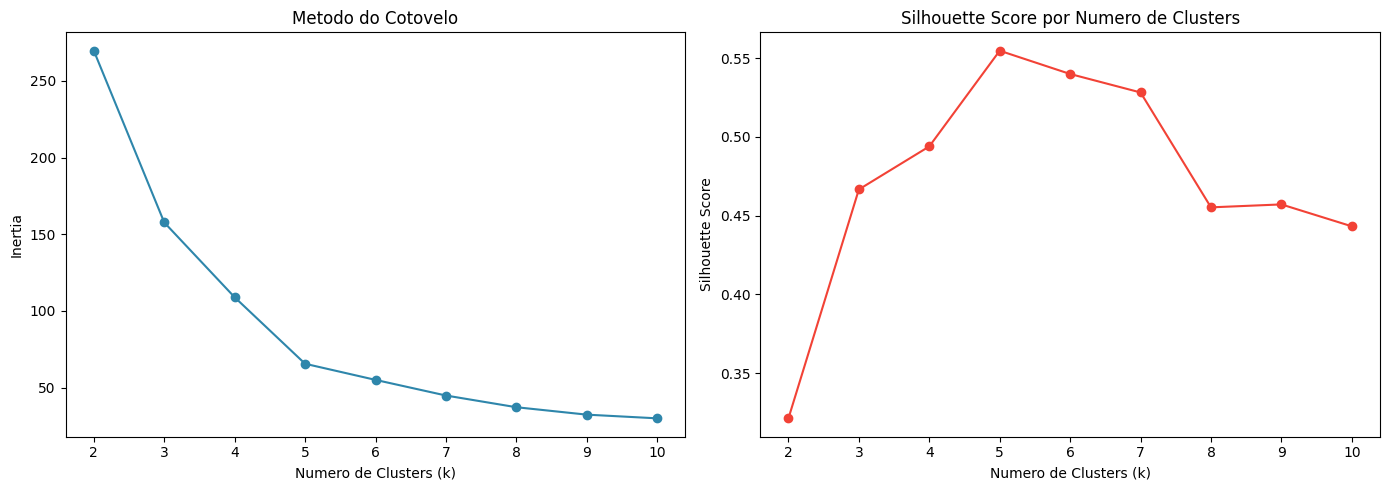

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(valores_k, inertias, marker='o', color='#2E86AB')
axes[0].set_title('Metodo do Cotovelo')
axes[0].set_xlabel('Numero de Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(valores_k, silhouettes, marker='o', color='#F24236')
axes[1].set_title('Silhouette Score por Numero de Clusters')
axes[1].set_xlabel('Numero de Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

O gráfico do cotovelo mostra uma queda acentuada da inércia até por volta de k=5, ponto a partir do qual a curva começa a achatar, o que já é um indício de que 5 é um bom número de clusters. Isso é confirmado pelo silhouette score, que atinge seu valor máximo em k=5 (aproximadamente 0.555), o maior entre todos os valores testados, indicando que essa é a quantidade de clusters que gera grupos mais coesos internamente e mais bem separados entre si. Por isso, foi escolhido k=5 para a segmentação final.



In [ ]:
# Treinando o modelo final de Kmeans com k=5

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

df['Cluster'].value_counts().sort_index()

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

# 4) Avaliação e Interpretação dos Resultados



In [ ]:
# Avaliando a qualidade do agrupamento final com o silhouette score

silhouette_final = silhouette_score(X_scaled, clusters)
print("Silhouette score do modelo final (k=5):", silhouette_final)

Silhouette score do modelo final (k=5): 0.5546571631111091


O silhouette score do modelo final ficou em aproximadamente 0.555. Como esse indicador varia de -1 a 1, sendo valores mais próximos de 1 sinal de clusters bem definidos e separados, um resultado acima de 0,5 indica uma segmentação de boa qualidade, com grupos razoavelmente coesos e distintos entre si.



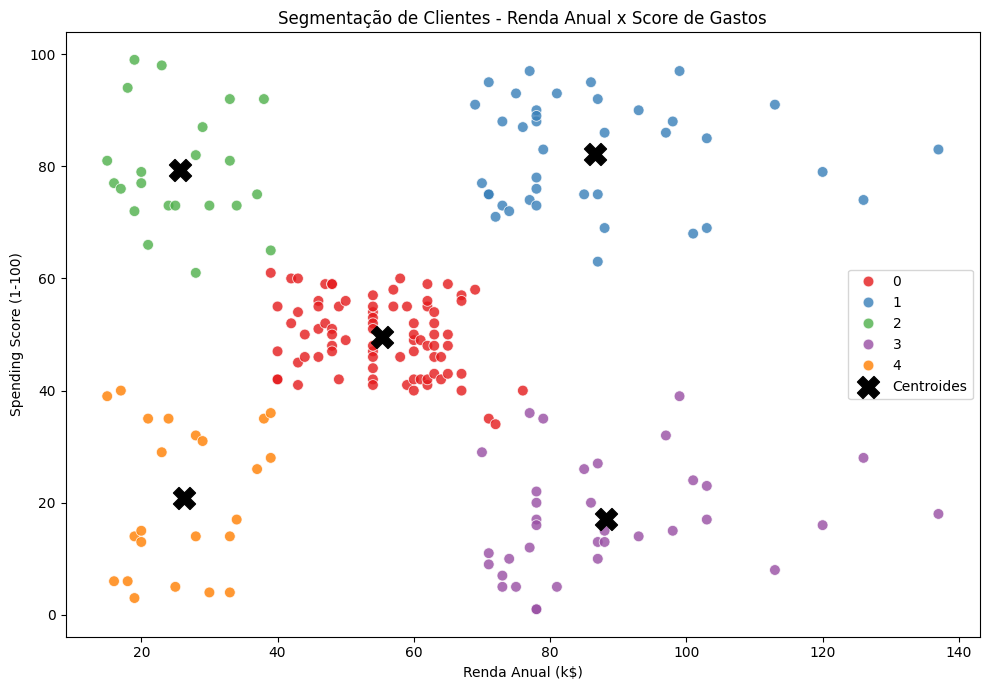

In [15]:
# Calculando os centróides na escala original, para plotar junto com os pontos
centroides_original = scaler.inverse_transform(kmeans.cluster_centers_)
centroides_df = pd.DataFrame(centroides_original, columns=colunas_cluster)

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Cluster', palette='Set1', s=60, alpha=0.8)
plt.scatter(centroides_df['Annual Income (k$)'], centroides_df['Spending Score (1-100)'],
            color='black', marker='X', s=250, label='Centroides')
plt.title('Segmentação de Clientes - Renda Anual x Score de Gastos')
plt.xlabel('Renda Anual (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Montando o perfil médio de cada cluster

perfil_clusters = df.groupby('Cluster').agg(
    Qtd_Clientes=('CustomerID', 'count'),
    Idade_Media=('Age', 'mean'),
    Renda_Media=('Annual Income (k$)', 'mean'),
    Score_Medio=('Spending Score (1-100)', 'mean'),
).round(1)

perfil_clusters

,Qtd_Clientes,Idade_Media,Renda_Media,Score_Medio
Cluster,,,,
0,81,42.7,55.3,49.5
1,39,32.7,86.5,82.1
2,22,25.3,25.7,79.4
3,35,41.1,88.2,17.1
4,23,45.2,26.3,20.9


In [ ]:
# Distribuição de gênero dentro de cada cluster

pd.crosstab(df['Cluster'], df['Gender'])

Gender,Female,Male
Cluster,,
0,48,33
1,21,18
2,13,9
3,16,19
4,14,9


Com base nas médias de cada grupo, é possível descrever 5 perfis de cliente bem distintos:

Cluster com renda e score médios (idade média em torno de 43 anos, renda média de 55k e score médio de 50): o cliente "padrão" do shopping, sem grandes extremos em renda ou consumo.

Cluster de renda alta e score alto (renda média de 86k e score médio de 82): os clientes mais valiosos, ganham bem e gastam bastante no shopping.

Cluster de renda baixa e score alto (renda média de 26k e score médio de 79): clientes jovens (idade média de 25 anos) que ganham pouco mas gastam proporcionalmente muito.

Cluster de renda alta e score baixo (renda média de 88k e score médio de 17): clientes que ganham bem, mas não costumam gastar no shopping, um público com potencial não aproveitado.

Cluster de renda baixa e score baixo (renda média de 26k e score médio de 21): clientes mais velhos (idade média de 45 anos), com pouca renda e pouco consumo no shopping.

Em relação ao gênero, a distribuição dentro de cada cluster segue proporção parecida com a da base geral, sem um cluster claramente dominado por um único gênero, ou seja, o comportamento de renda e consumo parece ser mais determinante para a segmentação do que o gênero em si nesta base.



# 5) Aplicações Práticas para os Clusters Identificados



Cliente padrão (renda e score médios): pode receber comunicações e promoções mais genéricas, com foco em fidelização, como programas de pontos ou cupons de desconto recorrentes, incentivando que ele suba de faixa de consumo aos poucos.

Renda alta e score alto (clientes ideais): merecem atenção especial, com ofertas exclusivas, atendimento VIP, acesso antecipado a lançamentos e produtos premium, já que são o público mais rentável e engajado.

Renda baixa e score alto (jovens gastadores): fazem bastante sentido para campanhas com parcelamento, cashback e promoções de produtos populares entre o público jovem, já que demonstram disposição para gastar mesmo com renda mais limitada.

Renda alta e score baixo (potencial não aproveitado): esse é o grupo mais estratégico para ações de reativação, como pesquisas de satisfação, cupons agressivos de primeira compra em novas categorias ou convites para eventos exclusivos, tentando entender por que, apesar da renda alta, esses clientes não estão gastando no shopping.

Renda baixa e score baixo (clientes mais velhos e menos engajados): campanhas de baixo custo, como promoções sazonais, descontos em categorias essenciais e comunicação mais simples, evitando investir pesado em um público com menor potencial de retorno imediato.